# Stress Level Prediction Model

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [ ]:
df = pd.read_csv(r"...\DataSet\StressLevelDataset.csv")
pd.set_option('display.max_column', None)

## Sneak Peak Dataset

In [5]:
df

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,3,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,2,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,3,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,2,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,4,3,4,3,1,2,1,5,0,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,11,17,0,14,3,1,3,2,2,2,2,3,2,2,2,3,3,2,3,3,1
1096,9,12,0,8,0,3,0,0,0,1,3,4,0,1,1,1,1,3,4,3,2
1097,4,26,0,3,1,2,5,2,2,3,4,4,5,1,4,1,3,1,2,1,0
1098,21,0,1,19,5,3,1,4,3,1,1,1,2,5,1,4,1,4,4,4,2


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    110

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64

In [11]:
df['stress_level'].unique() #this is our target column

array([1, 2, 0])

## Descriptive Analysis

- Eustress: Stres yang membangun dan meningkatkan kemampuan.
- Distress: Stres yang merusak dan menurunkan kualitas kesehatan.

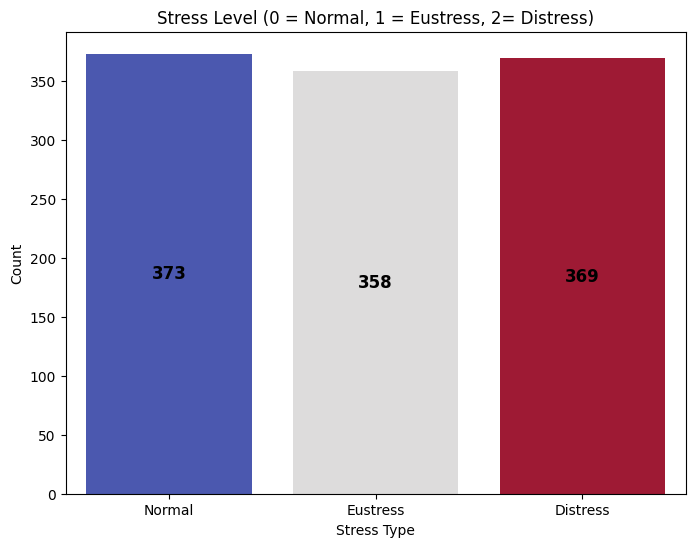

In [15]:
plt.figure(figsize=(8, 6))

# Gunakan `hue='diagnosis'` untuk menghindari FutureWarning
sns.countplot(x='stress_level', data=df, hue='stress_level', palette='coolwarm', legend=False)

# Tambahkan judul dan label Eustress, Distress, No Stress
plt.title('Stress Level (0 = Normal, 1 = Eustress, 2= Distress)')
plt.xlabel('Stress Type')
plt.ylabel('Count')
plt.xticks([0, 1, 2], ['Normal', 'Eustress', 'Distress'])

# Tambahkan label jumlah di tengah bar
for p in plt.gca().patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() / 2
    plt.text(x, y, str(count), ha='center', va='center', color='black', fontsize=12, fontweight='bold')

plt.show()

### Correlation Matrix

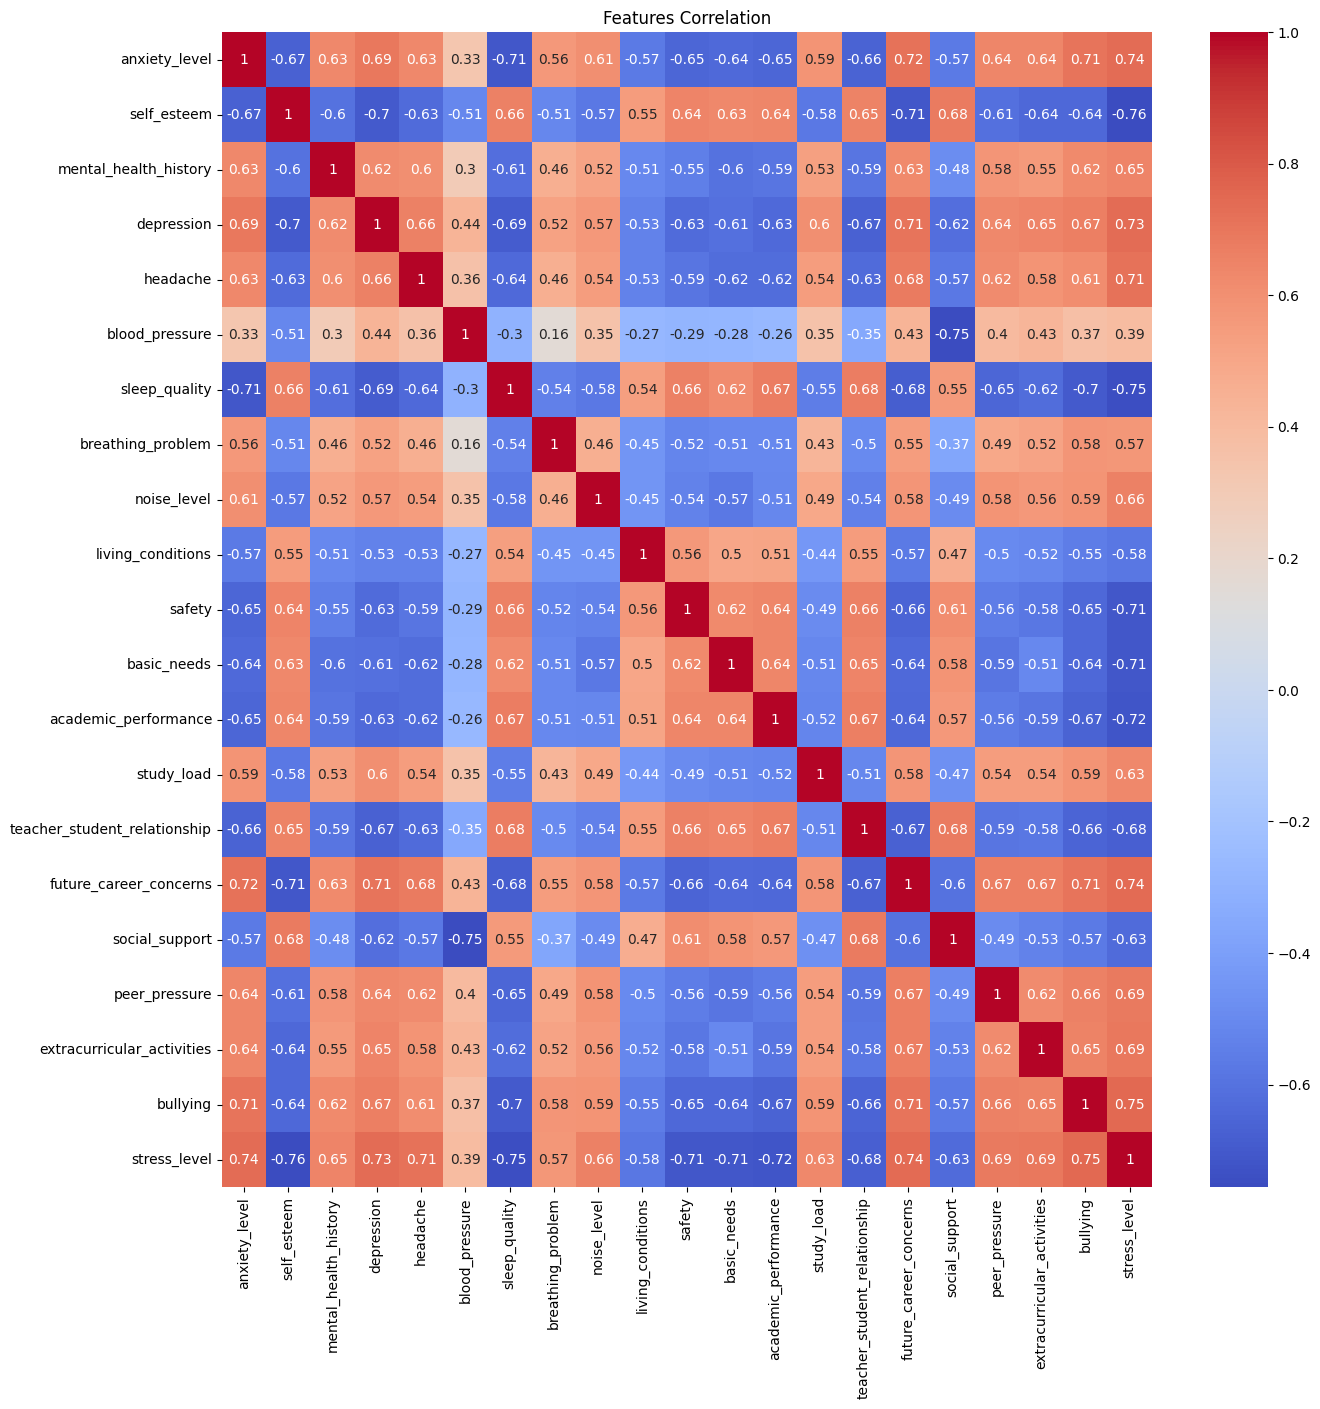

In [16]:
corr_matrix = df.corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Features Correlation')
plt.show()

In [19]:
df.columns

Index(['anxiety_level', 'self_esteem', 'mental_health_history', 'depression',
       'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem',
       'noise_level', 'living_conditions', 'safety', 'basic_needs',
       'academic_performance', 'study_load', 'teacher_student_relationship',
       'future_career_concerns', 'social_support', 'peer_pressure',
       'extracurricular_activities', 'bullying', 'stress_level'],
      dtype='object')

### Distribution Checking

In [21]:
# Ambil korelasi semua fitur terhadap 'diagnosis'
target_corr = corr_matrix['stress_level']

# Pilih fitur dengan korelasi tinggi (positif atau negatif) terhadap 'diagnosis'
selected_features = target_corr[(target_corr) >= 0.55].index.tolist()

# Cetak hasil fitur yang lolos seleksi
print("Features with Strong Correlation >= 0.6 atau <= -0.6 terhadap 'stress_level':")
print(selected_features)

Features with Strong Correlation >= 0.6 atau <= -0.6 terhadap 'stress_level':
['anxiety_level', 'mental_health_history', 'depression', 'headache', 'breathing_problem', 'noise_level', 'study_load', 'future_career_concerns', 'peer_pressure', 'extracurricular_activities', 'bullying', 'stress_level']


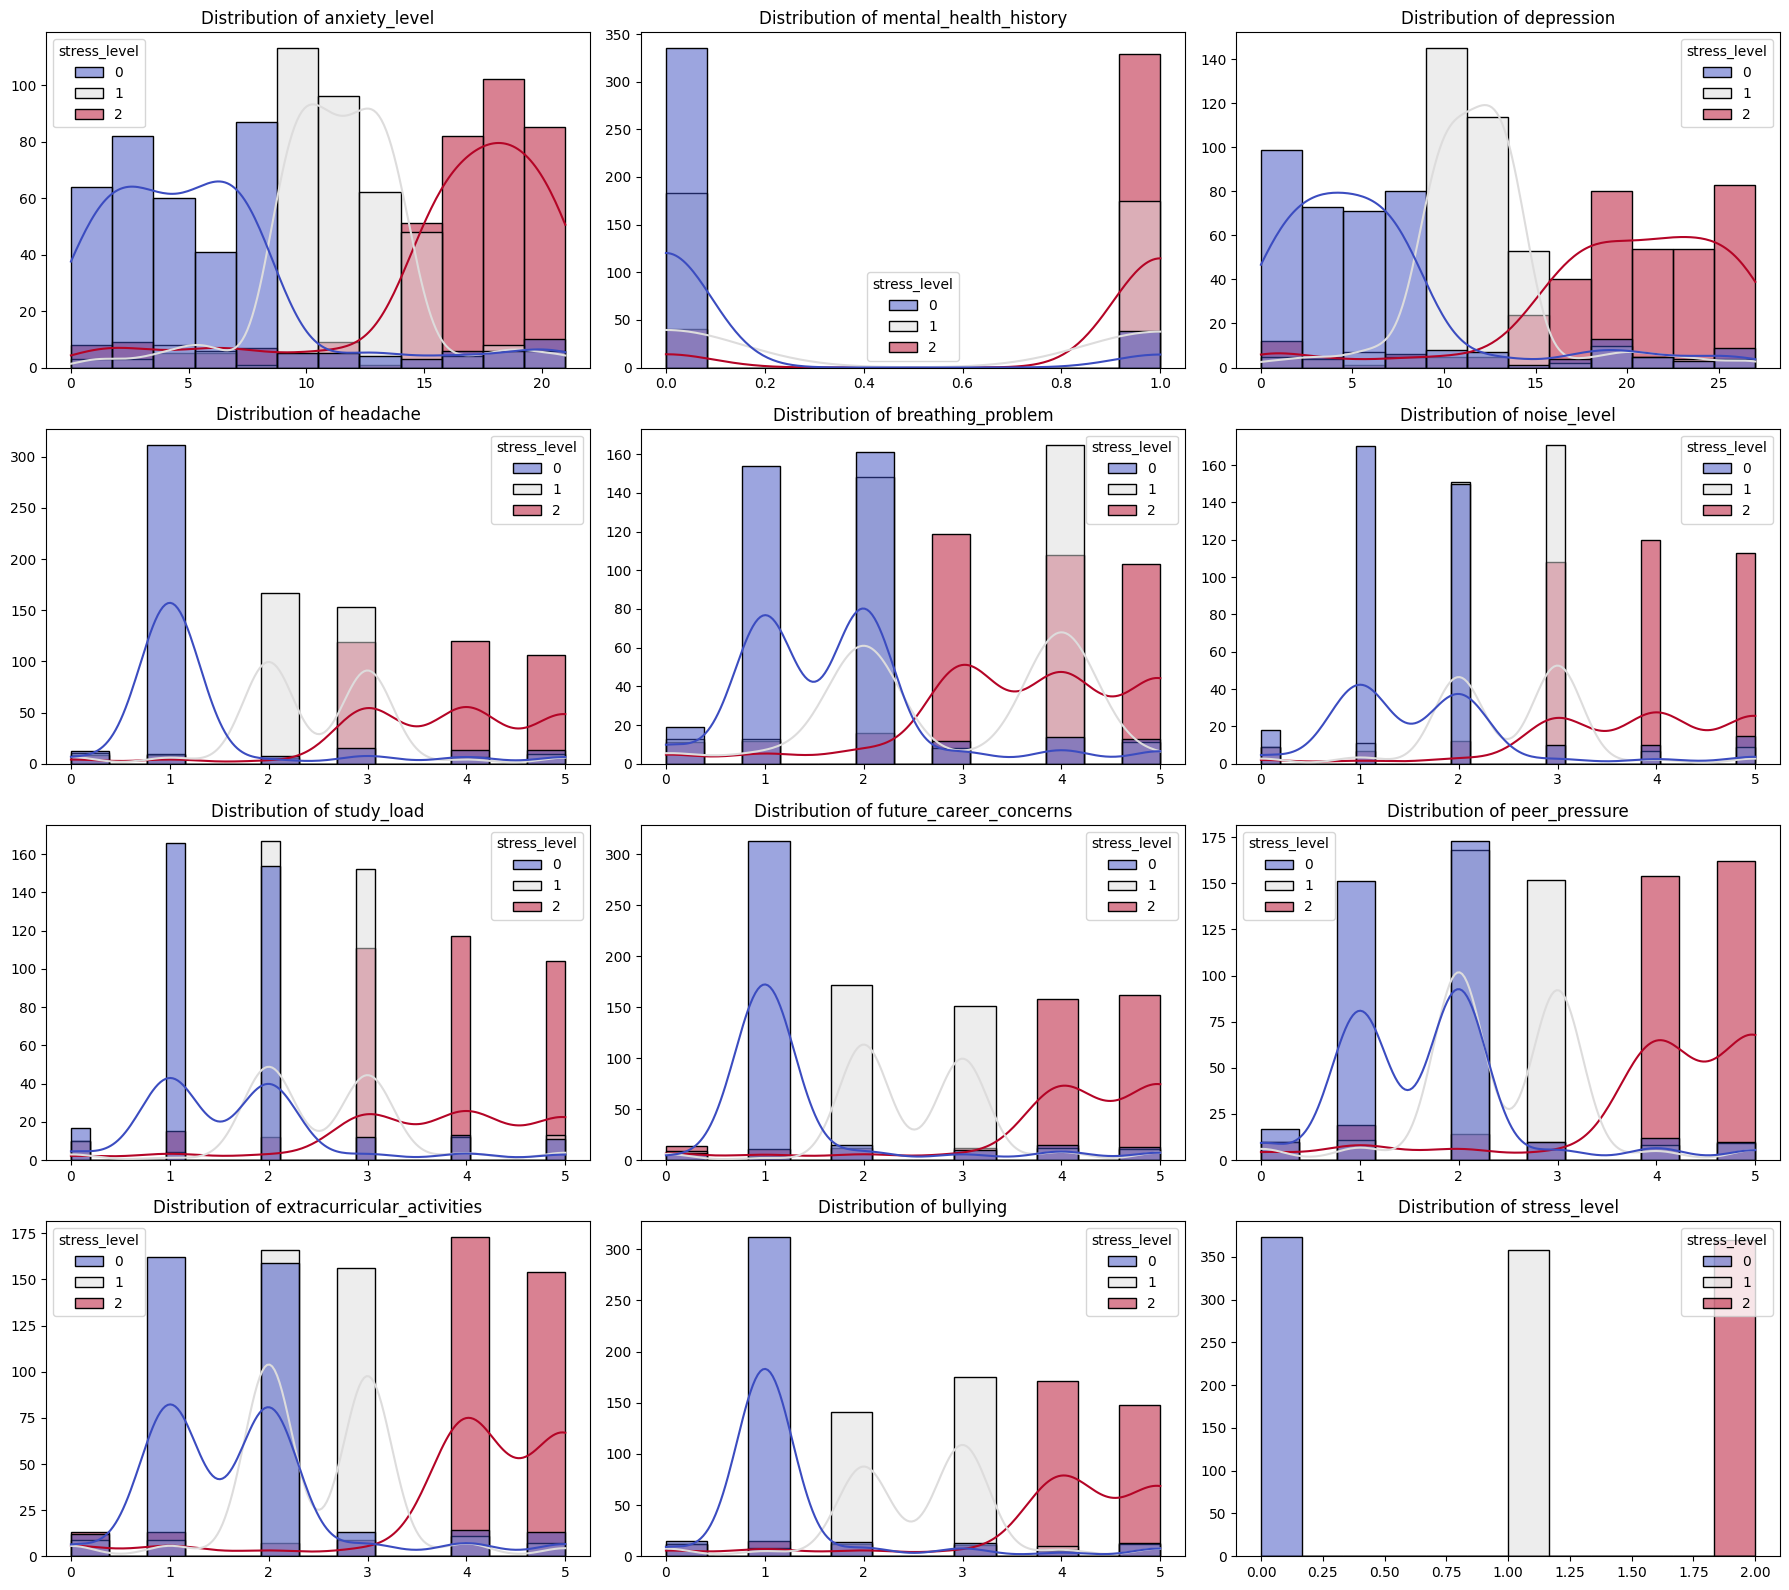

In [23]:
features_to_plot = [
    'anxiety_level', 'mental_health_history', 'depression', 'headache', 'breathing_problem', 'noise_level', 
    'study_load', 'future_career_concerns', 'peer_pressure', 'extracurricular_activities', 'bullying', 'stress_level'
]

plt.figure(figsize=(18, 16))  # perbesar figurenya untuk subplot 4x3
for i, feature in enumerate(features_to_plot):
    plt.subplot(4, 3, i + 1)  # 4 baris x 3 kolom = 12 subplot
    sns.histplot(data=df, x=feature, hue='stress_level', kde=True, palette='coolwarm')
    plt.title(f'Distribution of {feature}')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

### Outlier Checking

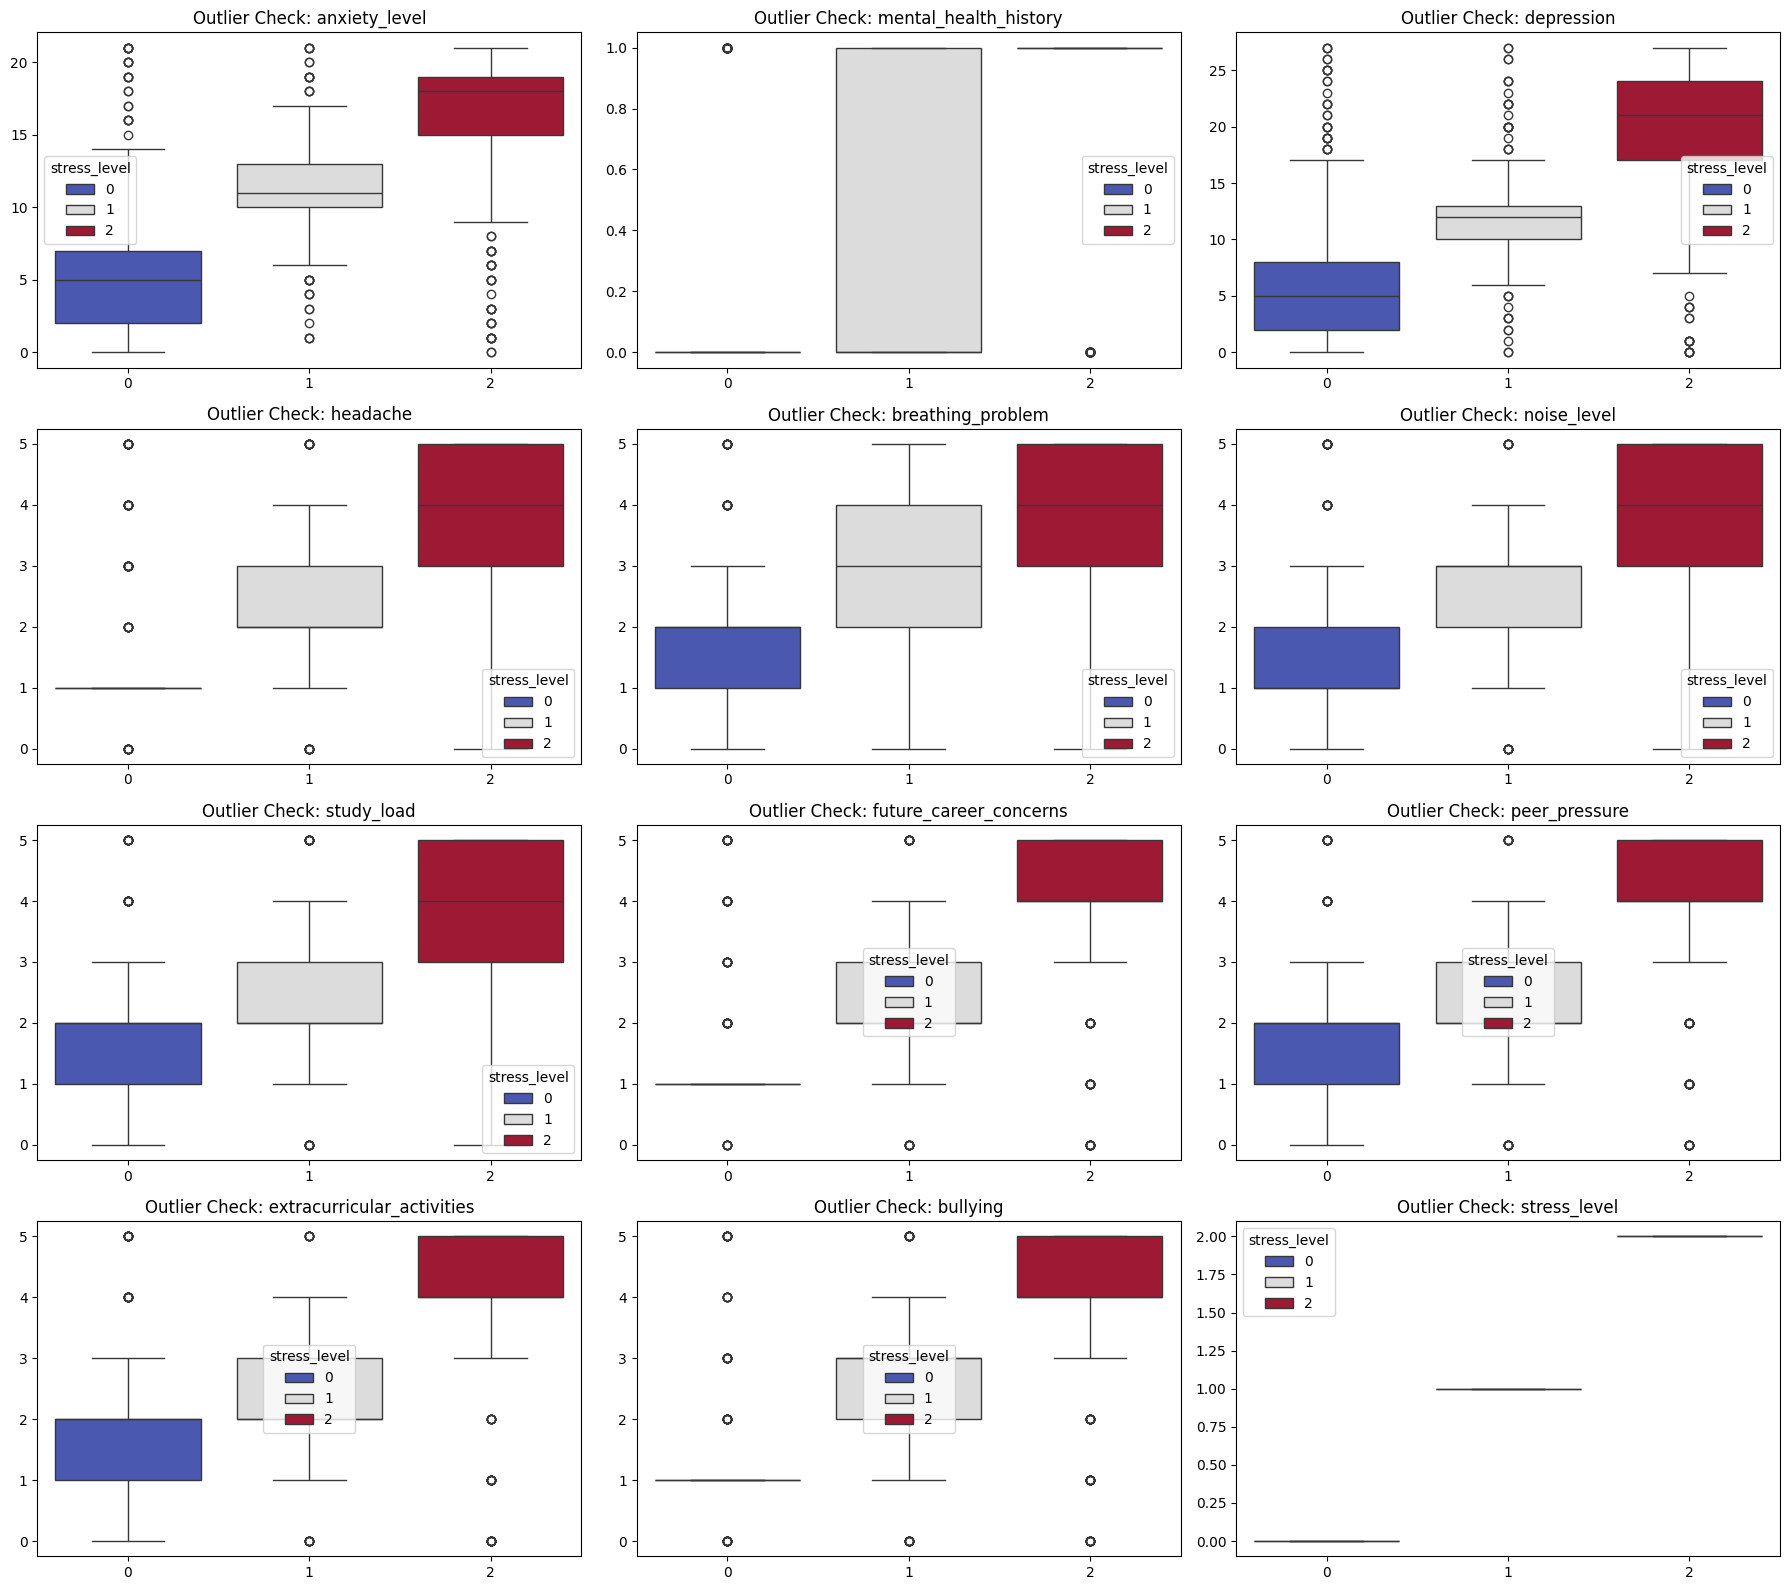

In [26]:
plt.figure(figsize=(18, 16))  # Ukuran figure besar untuk 12 subplot
for i, feature in enumerate(features_to_plot):
    plt.subplot(4, 3, i + 1)  # 4 baris x 3 kolom
    sns.boxplot(data=df, hue='stress_level', x='stress_level', y=feature, palette='coolwarm')
    plt.title(f'Outlier Check: {feature}')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

## Machine Learning

In [27]:
df_ML = df.copy()

In [28]:
df_ML.sample(5)

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
615,11,25,1,10,2,1,3,2,2,2,3,2,3,3,3,3,3,2,2,2,1
452,18,4,0,1,1,3,0,1,5,2,1,4,0,2,0,2,0,0,3,5,1
746,12,16,1,10,3,1,3,2,2,2,2,3,2,2,3,2,3,3,3,3,1
616,20,15,1,26,4,3,1,4,4,2,2,2,1,5,1,4,1,5,5,4,2
589,5,1,1,18,4,3,3,2,2,0,4,0,1,0,0,3,1,2,4,0,2


### Import Library

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

### Split Data Train/Test

In [30]:
X= df_ML.drop('stress_level', axis=1)
y= df_ML['stress_level']

print("Feature (X) dimension: ", X.shape)
print("Feature (y) dimension: ", y.shape)

Feature (X) dimension:  (1100, 20)
Feature (y) dimension:  (1100,)


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training Set Size: {X_train.shape[0]}")
print(f"Test Set Size: {X_test.shape[0]}")

Training Set Size: 880
Test Set Size: 220


### Modeling

In [33]:
selected_features = [
    'anxiety_level', 'mental_health_history', 'depression', 'headache', 'breathing_problem', 'noise_level', 
    'study_load', 'future_career_concerns', 'peer_pressure', 'extracurricular_activities', 'bullying'
]

scaler = StandardScaler()
X_train[selected_features] = scaler.fit_transform(X_train[selected_features])
X_test[selected_features] = scaler.transform(X_test[selected_features])

In [34]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'), 
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100), 
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM': SVC(random_state=42, probability=True, kernel='rbf'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'AdaBoost': AdaBoostClassifier(random_state=42, n_estimators=100)
}

In [35]:
trained_models = {}

for name, model in models.items():
    print(f"[{name}] The model is being trained...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"[{name}] model training is completed.")
    print()

print("\nAll models were trained successfully.")

[Logistic Regression] The model is being trained...
[Logistic Regression] model training is completed.

[Random Forest] The model is being trained...
[Random Forest] model training is completed.

[XGBoost] The model is being trained...
[XGBoost] model training is completed.

[SVM] The model is being trained...
[SVM] model training is completed.

[Gradient Boosting] The model is being trained...
[Gradient Boosting] model training is completed.

[KNN] The model is being trained...
[KNN] model training is completed.

[AdaBoost] The model is being trained...
[AdaBoost] model training is completed.


All models were trained successfully.


### Evaluation Model


--- Logistic Regression Evaluating the Model ---
Accuracy: 0.8773
F1 Score: 0.8775
ROC-AUC: 0.9640
Confusion Matrix:
 [[62  7  5]
 [ 4 66  2]
 [ 8  1 65]]


<Figure size 600x500 with 0 Axes>

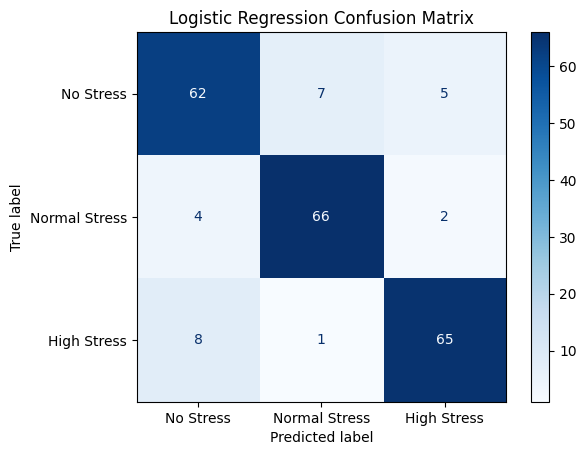


--- Random Forest Evaluating the Model ---
Accuracy: 0.8909
F1 Score: 0.8910
ROC-AUC: 0.9830
Confusion Matrix:
 [[62  3  9]
 [ 2 67  3]
 [ 3  4 67]]


<Figure size 600x500 with 0 Axes>

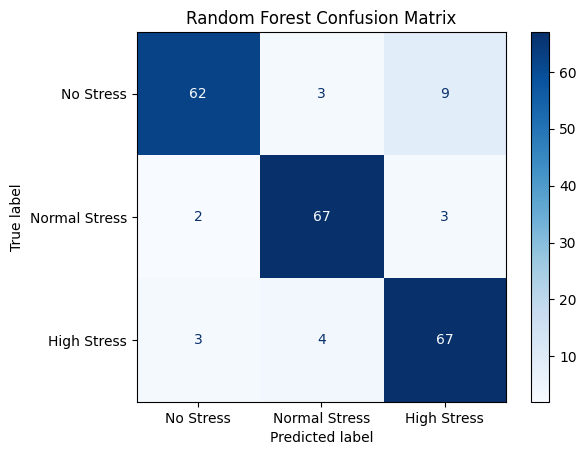


--- XGBoost Evaluating the Model ---
Accuracy: 0.8727
F1 Score: 0.8727
ROC-AUC: 0.9820
Confusion Matrix:
 [[62  6  6]
 [ 3 64  5]
 [ 5  3 66]]


<Figure size 600x500 with 0 Axes>

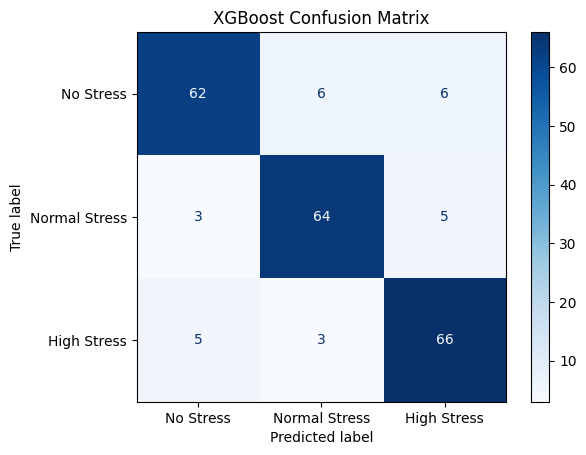


--- SVM Evaluating the Model ---
Accuracy: 0.8682
F1 Score: 0.8687
ROC-AUC: 0.9728
Confusion Matrix:
 [[59 10  5]
 [ 0 65  7]
 [ 1  6 67]]


<Figure size 600x500 with 0 Axes>

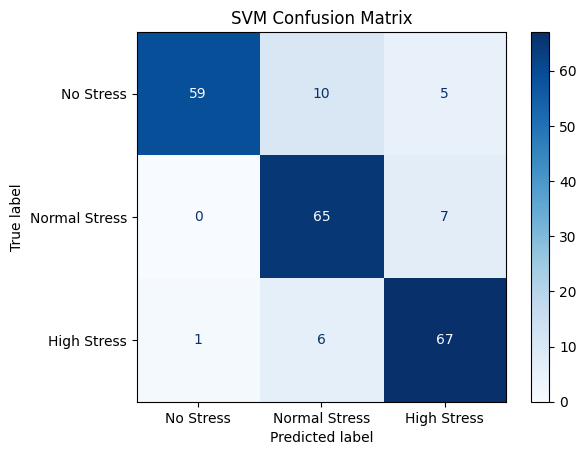


--- Gradient Boosting Evaluating the Model ---
Accuracy: 0.8727
F1 Score: 0.8724
ROC-AUC: 0.9826
Confusion Matrix:
 [[61  7  6]
 [ 1 67  4]
 [ 7  3 64]]


<Figure size 600x500 with 0 Axes>

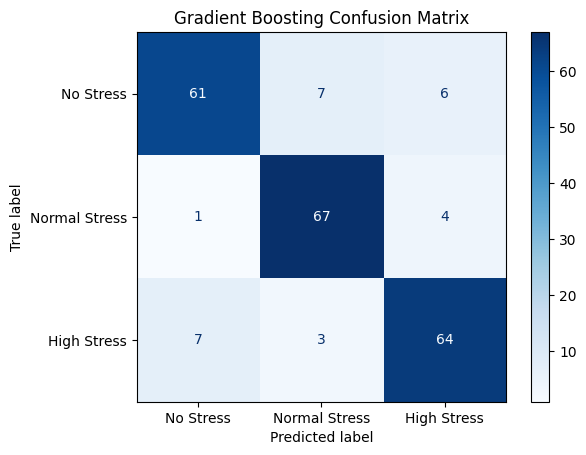


--- KNN Evaluating the Model ---
Accuracy: 0.8636
F1 Score: 0.8634
ROC-AUC: 0.9355
Confusion Matrix:
 [[60  8  6]
 [ 3 65  4]
 [ 4  5 65]]


<Figure size 600x500 with 0 Axes>

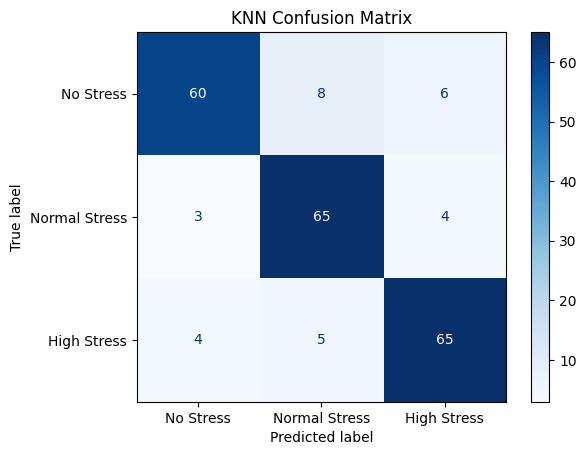


--- AdaBoost Evaluating the Model ---
Accuracy: 0.8864
F1 Score: 0.8860
ROC-AUC: 0.9744
Confusion Matrix:
 [[60  6  8]
 [ 1 67  4]
 [ 3  3 68]]


<Figure size 600x500 with 0 Axes>

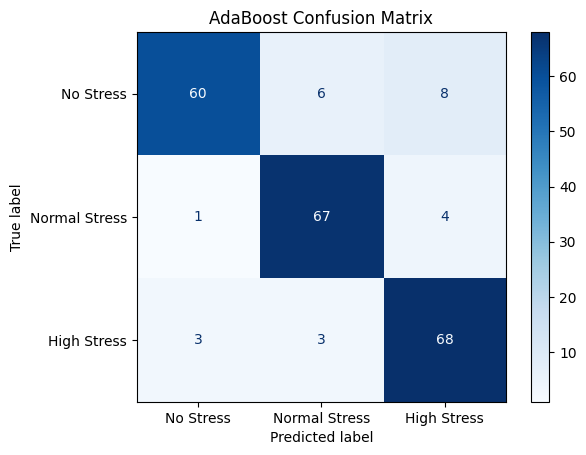

In [41]:
results = {}

for name, model in trained_models.items():
    print(f"\n--- {name} Evaluating the Model ---")

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')  # bisa juga 'weighted' / micro
    roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        'Accuracy': accuracy,
        'F1 Score': f1,
        'ROC-AUC': roc_auc,
        'Confusion Matrix': cm
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print("Confusion Matrix:\n", cm)

    plt.figure(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stress', 'Normal Stress', 'High Stress'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'{name} Confusion Matrix')
    plt.show()

### Summary Report

In [42]:
print("Performance Summary of All Models:\n")
for name, metrics in results.items():
    print(f"Model: {name}")
    print(f"  Accuracy: {metrics['Accuracy']:.4f}")
    print(f"  F1 Score: {metrics['F1 Score']:.4f}")
    print(f"  ROC-AUC: {metrics['ROC-AUC']:.4f}")
    print("-" * 30)

Performance Summary of All Models:

Model: Logistic Regression
  Accuracy: 0.8773
  F1 Score: 0.8775
  ROC-AUC: 0.9640
------------------------------
Model: Random Forest
  Accuracy: 0.8909
  F1 Score: 0.8910
  ROC-AUC: 0.9830
------------------------------
Model: XGBoost
  Accuracy: 0.8727
  F1 Score: 0.8727
  ROC-AUC: 0.9820
------------------------------
Model: SVM
  Accuracy: 0.8682
  F1 Score: 0.8687
  ROC-AUC: 0.9728
------------------------------
Model: Gradient Boosting
  Accuracy: 0.8727
  F1 Score: 0.8724
  ROC-AUC: 0.9826
------------------------------
Model: KNN
  Accuracy: 0.8636
  F1 Score: 0.8634
  ROC-AUC: 0.9355
------------------------------
Model: AdaBoost
  Accuracy: 0.8864
  F1 Score: 0.8860
  ROC-AUC: 0.9744
------------------------------


### Bar Plot Model

In [43]:
# Convert results dict to DataFrame
metrics_df = pd.DataFrame(results).T[['Accuracy', 'F1 Score', 'ROC-AUC']]
metrics_df = metrics_df.sort_values('ROC-AUC', ascending=False)

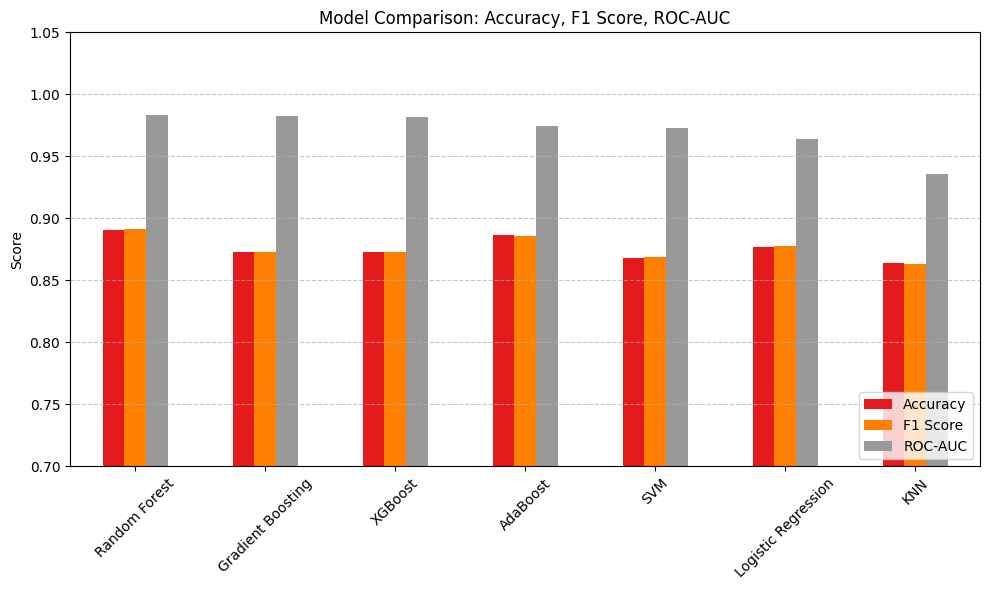

In [44]:
# Plot
metrics_df.plot(kind='bar', figsize=(10, 6), colormap='Set1')
plt.title("Model Comparison: Accuracy, F1 Score, ROC-AUC")
plt.ylabel("Score")
plt.ylim(0.7, 1.05)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### ROC-Curve

In [46]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

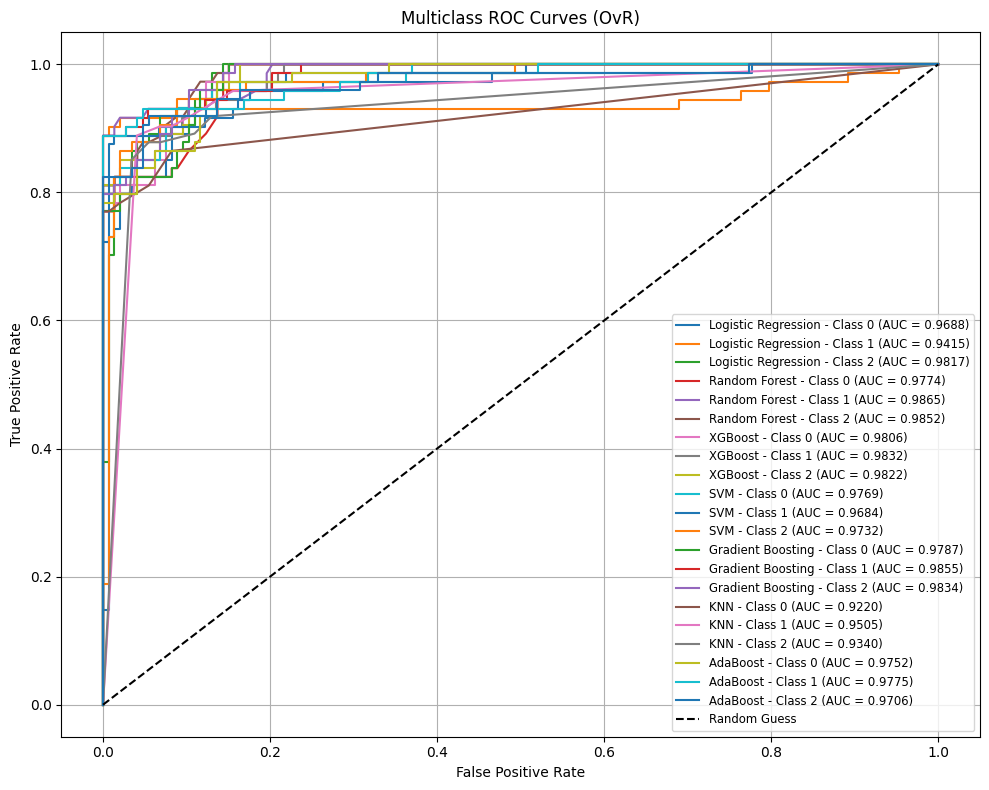

In [48]:
# Binarize the output (e.g., [0,1,2] → one-hot vectors)
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(10, 8))

for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test)  # shape = [n_samples, n_classes]
    
    # Compute ROC curve and ROC area for each class (OvR)
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} - Class {classes[i]} (AUC = {roc_auc:.4f})')

# Reference line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.title('Multiclass ROC Curves (OvR)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()

## Machine Leaning V.2

### ⚠️ Evaluasi Overfitting

In [55]:
print("==== Overfitting Check ====\n")

for name, model in trained_models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    y_train_proba = model.predict_proba(X_train) #[:, 1]
    y_test_proba = model.predict_proba(X_test) #[:, 1]

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    test_f1 = f1_score(y_test, y_test_pred, average='macro')

    train_auc = roc_auc_score(y_train, y_train_proba, multi_class='ovr')
    test_auc = roc_auc_score(y_test, y_test_proba, multi_class='ovr')

    print(f"Model: {name}")
    print(f"  Train Accuracy : {train_acc:.4f} | Test Accuracy : {test_acc:.4f}")
    print(f"  Train F1 Score : {train_f1:.4f} | Test F1 Score : {test_f1:.4f}")
    print(f"  Train ROC-AUC  : {train_auc:.4f} | Test ROC-AUC  : {test_auc:.4f}")
    print("-" * 50)

==== Overfitting Check ====

Model: Logistic Regression
  Train Accuracy : 0.8898 | Test Accuracy : 0.8773
  Train F1 Score : 0.8901 | Test F1 Score : 0.8775
  Train ROC-AUC  : 0.9794 | Test ROC-AUC  : 0.9640
--------------------------------------------------
Model: Random Forest
  Train Accuracy : 1.0000 | Test Accuracy : 0.8909
  Train F1 Score : 1.0000 | Test F1 Score : 0.8910
  Train ROC-AUC  : 1.0000 | Test ROC-AUC  : 0.9830
--------------------------------------------------
Model: XGBoost
  Train Accuracy : 1.0000 | Test Accuracy : 0.8727
  Train F1 Score : 1.0000 | Test F1 Score : 0.8727
  Train ROC-AUC  : 1.0000 | Test ROC-AUC  : 0.9820
--------------------------------------------------
Model: SVM
  Train Accuracy : 0.8943 | Test Accuracy : 0.8682
  Train F1 Score : 0.8946 | Test F1 Score : 0.8687
  Train ROC-AUC  : 0.9848 | Test ROC-AUC  : 0.9728
--------------------------------------------------
Model: Gradient Boosting
  Train Accuracy : 1.0000 | Test Accuracy : 0.8727
  Tra

### ⚠️ Validasi Silang (Stratified K-Fold Cross-Validation)

In [96]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, make_scorer

In [97]:
print("\n==== Cross-Validation (StratifiedKFold) ====\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Gunakan scorer khusus untuk multiclass
f1_macro = make_scorer(f1_score, average='macro')

for name, model in trained_models.items():
    auc_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc_ovr')
    f1_scores = cross_val_score(model, X, y, cv=cv, scoring=f1_macro)
    acc_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

    print(f"Model: {name}")
    print(f"  Mean Accuracy : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
    print(f"  Mean F1 Score : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
    print(f"  Mean ROC-AUC  : {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")
    print("-" * 50)


==== Cross-Validation (StratifiedKFold) ====

Model: Logistic Regression
  Mean Accuracy : 0.8891 ± 0.0179
  Mean F1 Score : 0.8896 ± 0.0175
  Mean ROC-AUC  : 0.9639 ± 0.0084
--------------------------------------------------
Model: Random Forest
  Mean Accuracy : 0.8855 ± 0.0145
  Mean F1 Score : 0.8857 ± 0.0146
  Mean ROC-AUC  : 0.9836 ± 0.0039
--------------------------------------------------
Model: XGBoost
  Mean Accuracy : 0.8745 ± 0.0190
  Mean F1 Score : 0.8748 ± 0.0190
  Mean ROC-AUC  : 0.9827 ± 0.0030
--------------------------------------------------
Model: SVM
  Mean Accuracy : 0.8873 ± 0.0060
  Mean F1 Score : 0.8873 ± 0.0059
  Mean ROC-AUC  : 0.9779 ± 0.0057
--------------------------------------------------
Model: Gradient Boosting
  Mean Accuracy : 0.8873 ± 0.0142
  Mean F1 Score : 0.8872 ± 0.0140
  Mean ROC-AUC  : 0.9838 ± 0.0025
--------------------------------------------------
Model: KNN
  Mean Accuracy : 0.8745 ± 0.0130
  Mean F1 Score : 0.8745 ± 0.0131
  Mean ROC

## Hyperparameter Tuning Model

### 🎯 Tuning Random Forest

#### ✅ Tuning with RandomizedSearchCV

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [59]:
# Definisikan parameter grid
param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

In [60]:
# Inisialisasi model dasar
rf = RandomForestClassifier(random_state=42)

In [61]:
# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,  # jumlah kombinasi yang dicoba
    cv=5,       # 5-fold cross-validation
    scoring='f1_macro',  # atau 'accuracy', 'roc_auc_ovr'
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [62]:
# Jalankan pencarian
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001AD49549950>,
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001AD41969CD0>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001AD49549BD0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001AD48FCD550>},
                   random_state=42, scoring='f1_macro', verbose=1)

In [63]:
# Model terbaik
best_rf = random_search.best_estimator_

In [64]:
print("Best parameters found:")
print(random_search.best_params_)

Best parameters found:
{'bootstrap': False, 'max_depth': 14, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 9, 'n_estimators': 145}


#### Evaluation Tuning Model

In [65]:
from sklearn.metrics import classification_report

y_pred = best_rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85        74
           1       0.79      0.89      0.84        72
           2       0.87      0.82      0.85        74

    accuracy                           0.85       220
   macro avg       0.85      0.85      0.85       220
weighted avg       0.85      0.85      0.85       220



### 🎯 Tuning XGBoost

#### Impoertance Parameter in XGBoost

| Parameter          | Fungsi                                     |
| ------------------ | ------------------------------------------ |
| `n_estimators`     | Jumlah boosting rounds                     |
| `max_depth`        | Kedalaman maksimum pohon                   |
| `learning_rate`    | Ukuran langkah tiap boosting               |
| `subsample`        | Proporsi data yang digunakan tiap tree     |
| `colsample_bytree` | Proporsi fitur yang digunakan tiap pohon   |
| `gamma`            | Minimum loss reduction untuk membuat split |
| `reg_alpha`        | L1 regularization (sparsity)               |
| `reg_lambda`       | L2 regularization                          |

#### ✅ Tuning with RandomizedSearchCV for XGBoost

In [66]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [74]:
# Inisialisasi model
xgb = XGBClassifier(eval_metric='mlogloss', random_state=42) #use_label_encoder=False, 

In [75]:
# Parameter grid
param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 15),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'gamma': uniform(0, 5),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1)
}

In [76]:
# RandomizedSearchCV setup
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='f1_macro',  # atau 'roc_auc_ovr', 'accuracy'
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [77]:
# Jalankan tuning
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_con...
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001AD48B59E10>,
                                        'reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001AD4954D130>,
                                        'reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001AD4954CE60>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001AD48B5A360>},
                   random_state=42, scoring='f1_macro', verbose=1)

In [78]:
# Model terbaik
best_xgb = random_search.best_estimator_

In [79]:
print("Best XGBoost Parameters:")
print(random_search.best_params_)

Best XGBoost Parameters:
{'colsample_bytree': np.float64(0.6110539052353652), 'gamma': np.float64(0.599326836668414), 'learning_rate': np.float64(0.11128455142108838), 'max_depth': 13, 'n_estimators': 167, 'reg_alpha': np.float64(0.21876421957307024), 'reg_lambda': np.float64(0.5581020020173412), 'subsample': np.float64(0.7019180855290204)}


#### Evaluation Tuning Model

In [80]:
y_pred = best_xgb.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.82      0.87        74
           1       0.85      0.89      0.87        72
           2       0.86      0.91      0.88        74

    accuracy                           0.87       220
   macro avg       0.87      0.87      0.87       220
weighted avg       0.87      0.87      0.87       220



### 🎯 Tuning Gradient Boosting

#### 🔧 Importance Hyperparameter Gradient Boosting

| Parameter           | Fungsi                                          |
| ------------------- | ----------------------------------------------- |
| `n_estimators`      | Jumlah boosting rounds (pohon)                  |
| `learning_rate`     | Ukuran langkah dalam memperbaiki kesalahan      |
| `max_depth`         | Kedalaman maksimum pohon                        |
| `min_samples_split` | Minimum jumlah sampel untuk split node          |
| `min_samples_leaf`  | Minimum jumlah sampel di daun                   |
| `subsample`         | Proporsi data yang digunakan untuk setiap pohon |
| `max_features`      | Fitur yang digunakan saat split                 |


#### ✅ Tuning Gradient Boosting with RandomizedSearchCV

In [81]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [82]:
# Inisialisasi model
gb = GradientBoostingClassifier(random_state=42)

In [83]:
# Parameter distribusi
param_dist = {
    'n_estimators': randint(50, 300),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'subsample': uniform(0.6, 0.4),
    'max_features': ['sqrt', 'log2', None]
}

In [84]:
# RandomizedSearchCV setup
random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [85]:
# Jalankan tuning
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001AD48926B30>,
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001AD491E1650>,
                                        'max_features': ['sqrt', 'log2', None],
                                        'mi...AD4954E210>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001AD4954C5F0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001AD491E1050>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001AD48927230>},
                   random_state=42, scoring='f1_macro', verbose=1)

In [86]:
# Simpan model terbaik
best_gb = random_search.best_estimator_

In [87]:
print("Best Gradient Boosting Parameters:")
print(random_search.best_params_)

Best Gradient Boosting Parameters:
{'learning_rate': np.float64(0.043015577358303025), 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 9, 'min_samples_split': 5, 'n_estimators': 254, 'subsample': np.float64(0.9442922333025374)}


#### Evaluation Tuning Model

In [88]:
y_pred = best_gb.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.85      0.87        74
           1       0.91      0.93      0.92        72
           2       0.88      0.89      0.89        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



### 🧪 Evaluation & Summary All Model

In [89]:
# Model final
final_models = {
    'Logistic Regression': trained_models['Logistic Regression'],
    'SVM': trained_models['SVM'],
    'AdaBoost': trained_models['AdaBoost'],
    'KNN': trained_models['KNN'],
    'Random Forest (Tuned)': best_rf,
    'XGBoost (Tuned)': best_xgb,
    'Gradient Boosting (Tuned)': best_gb
}

In [91]:
# Evaluasi semua model
summary = {}

for name, model in final_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)  # multiclass

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    roc = roc_auc_score(y_test, y_proba, multi_class='ovr')

    summary[name] = {
        'Accuracy': acc,
        'F1 Score': f1,
        'ROC-AUC': roc
    }

In [92]:
# Tampilkan hasil
print("📊 Model Performance Summary (After Tuning):\n")
for model_name, metrics in summary.items():
    print(f"Model: {model_name}")
    print(f"  Accuracy : {metrics['Accuracy']:.4f}")
    print(f"  F1 Score : {metrics['F1 Score']:.4f}")
    print(f"  ROC-AUC  : {metrics['ROC-AUC']:.4f}")
    print("-" * 50)

📊 Model Performance Summary (After Tuning):

Model: Logistic Regression
  Accuracy : 0.8773
  F1 Score : 0.8775
  ROC-AUC  : 0.9640
--------------------------------------------------
Model: SVM
  Accuracy : 0.8682
  F1 Score : 0.8687
  ROC-AUC  : 0.9728
--------------------------------------------------
Model: AdaBoost
  Accuracy : 0.8864
  F1 Score : 0.8860
  ROC-AUC  : 0.9744
--------------------------------------------------
Model: KNN
  Accuracy : 0.8636
  F1 Score : 0.8634
  ROC-AUC  : 0.9355
--------------------------------------------------
Model: Random Forest (Tuned)
  Accuracy : 0.8455
  F1 Score : 0.8457
  ROC-AUC  : 0.9556
--------------------------------------------------
Model: XGBoost (Tuned)
  Accuracy : 0.8727
  F1 Score : 0.8725
  ROC-AUC  : 0.9841
--------------------------------------------------
Model: Gradient Boosting (Tuned)
  Accuracy : 0.8909
  F1 Score : 0.8909
  ROC-AUC  : 0.9838
--------------------------------------------------


### 📊 Vizualisation (Bar Chart)

In [93]:
# Ekstrak data
model_names = list(summary.keys())
accuracy_vals = [v['Accuracy'] for v in summary.values()]
f1_vals = [v['F1 Score'] for v in summary.values()]
roc_vals = [v['ROC-AUC'] for v in summary.values()]

x = range(len(model_names))

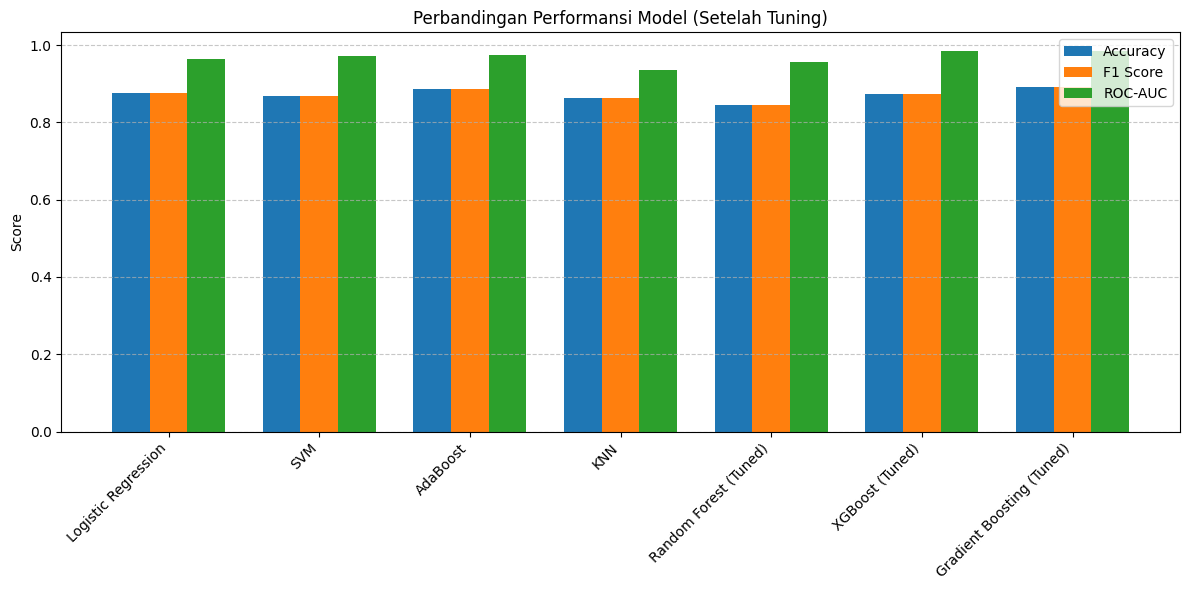

In [94]:
# Plot
plt.figure(figsize=(12, 6))
bar_width = 0.25

plt.bar(x, accuracy_vals, width=bar_width, label='Accuracy')
plt.bar([i + bar_width for i in x], f1_vals, width=bar_width, label='F1 Score')
plt.bar([i + 2*bar_width for i in x], roc_vals, width=bar_width, label='ROC-AUC')

plt.xticks([i + bar_width for i in x], model_names, rotation=45, ha='right')
plt.ylabel('Score')
plt.title('Perbandingan Performansi Model (Setelah Tuning)')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Summary and Conclusion

### 📊 Rangkuman Performa Semua Model (Setelah Tuning)

| Model                     | Accuracy   | F1 Score   | ROC-AUC    |
| ------------------------- | ---------- | ---------- | ---------- |
| Gradient Boosting (Tuned) ✅ | **0.8909** | **0.8909** | 0.9838     |
| AdaBoost                  | 0.8864     | 0.8860     | 0.9744     |
| Logistic Regression       | 0.8773     | 0.8775     | 0.9640     |
| XGBoost (Tuned)           | 0.8727     | 0.8725     | **0.9841** |
| SVM                       | 0.8682     | 0.8687     | 0.9728     |
| KNN                       | 0.8636     | 0.8634     | 0.9355     |
| Random Forest (Tuned)     | 0.8455     | 0.8457     | 0.9556     |


### 🏆 Rekomendasi Model Final

✅ Best Overall Model: Gradient Boosting (Tuned)
- Highest F1 Score → good for multiclass
- Highest Accuracy
- Very high ROC-AUC (0.9838) → almost equivalent to XGBoost
- Already tuned → maximum performance + controlled overfitting

🔁 Runner-Up: AdaBoost
- Very stable and lightweight
- Performance close to Gradient Boosting
- Suitable for real-time use cases/fast inference

⚠️ Warning:
- Random Forest (Tuned) actually decreased in performance after tuning → possibly too underfit (parameters too strict)
- XGBoost has the highest ROC-AUC, but lower F1 and Accuracy → if you prioritize ROC-AUC (e.g. minority case detection), this could be an option